# Imports

In [213]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random

from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_convert
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw

from ipywidgets import FloatProgress
import math 
from torch.nn.modules.batchnorm import _BatchNorm

# Setup

We just specify the best backend available for operations

In [214]:
if torch.backends.mps.is_available():
    print("MPS backend is available.")
    device = torch.device('mps')
elif torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

MPS backend is available.


In [215]:
device = torch.device('cpu')

In [216]:
zeroshotYolo = True

As per request of the assignment we resorted to clip based on a ResNet50 to be the core of our architecture

In [217]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

compute_iou function is just an helper function for calculating the Intersection over Union of two bboxes. 
The bboxes need to be served as a list of coordinates served as $[x_1,y_1,x_2,y_2]$

In [218]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding 

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

The LossMeter class has been created to help keeping track of the different values during training stages for all the different experiments

In [219]:
class MetricMeter:
    def __init__(self, name="Default", threshold = 0.5, log_dir='./logs/default_run'):
        self.name = name
        self.metrics = []
        self.epochs = []
        self.threshold = threshold
        self.reset()
        self.best_cases_iou = []  # To store the best cases
        self.worst_cases_iou = []
        self.best_cases_sim = []  # To store the best cases
        self.worst_cases_sim = []
        self.writer = SummaryWriter(log_dir=log_dir)

# TODO add SummaryWriter to plot

    def reset(self):
        self.count = 0
        self.iou = 0
        self.epoch = 0
        self.correct_bboxes, self.overall = 0,0
        self.semantic = 0
        self.metrics = []
    
    def add_best_iou(self, item):
        if len(self.best_cases_iou) < 5:
            self.best_cases_iou.append(item)
        else:
            min_best_case = min(self.best_cases_iou, key=lambda x: (x['iou']))
            if item['iou'] > min_best_case['iou']:
                self.best_cases_iou.remove(min_best_case)
                self.best_cases_iou.append(item)
    
    def add_worst_iou(self, item):
        if len(self.worst_cases_iou) < 5:
            self.worst_cases_iou.append(item)
        else:
            max_worst_case = max(self.worst_cases_iou, key=lambda x: (x['iou']))
            if (item['iou'] < max_worst_case['iou']):
                self.worst_cases_iou.remove(max_worst_case)
                self.worst_cases_iou.append(item)
    
    def add_best_confidence(self, item):
        if len(self.best_cases_sim) < 5:
            self.best_cases_sim.append(item)
        else:
            min_best_case = min(self.best_cases_sim, key=lambda x: (x['confidence']))
            if item['confidence'] > min_best_case['confidence']:
                self.best_cases_sim.remove(min_best_case)
                self.best_cases_sim.append(item)
    
    def add_worst_confidence(self, item):
        if len(self.worst_cases_sim) < 5:
            self.worst_cases_sim.append(item)
        else:
            max_worst_case = max(self.worst_cases_sim, key=lambda x: (x['confidence']))
            if (item['confidence'] < max_worst_case['confidence']):
                self.worst_cases_sim.remove(max_worst_case)
                self.worst_cases_sim.append(item)


    def update(self, iou, confidence,filename,bbox_e,bbox_gt):
        self.count += 1
        self.iou += iou
        if(iou >= self.threshold):
            self.correct_bboxes += 1
        self.semantic += confidence

        iteration = {
            'run_loc_acc': self.iou / self.count,
            'run_gro_acc': self.correct_bboxes / self.count,
            'run_sem_acc': self.semantic / self.count,
        }

        item = {
            'iou': iou,
            'confidence':confidence,
            'ground_truth': bbox_gt,
            'candidate': bbox_e,
            'path':filename
        }
        self.metrics.append([iteration])
        self.add_best_confidence(item)
        self.add_worst_confidence(item)
        self.add_best_iou(item)
        self.add_worst_iou(item)
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.count)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.count)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.count)

    def new_epoch(self):
        self.epoch += 1
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.epoch)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.epoch)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.epoch)
        self.epochs.append(self.metrics,self.best_cases_iou,self.best_cases_sim,self.worst_cases_iou,self.worst_cases_sim)
        self.reset()

    def __repr__(self):
        text = f"{self.name}: {self.avg:.8f}"
        return text
    
    def print_iteration(self):
        print(f"Localization accuracy = {self.iou / self.count}, Grounding Accuracy = {self.correct_bboxes / self.count}, Semantic Similarity = {self.semantic / self.count}")

    def get_best_iou_cases(self):
        return sorted(self.best_cases_iou, key=lambda x: x['iou'], reverse=True)

    def get_worst_iou_cases(self):
        return sorted(self.worst_cases_iou, key=lambda x: x['iou'])

    def get_best_pred_cases(self):
        return sorted(self.best_cases_sim, key=lambda x: x['confidence'], reverse=True)

    def get_worst_pred_cases(self):
        return sorted(self.worst_cases_sim, key=lambda x: x['confidence'])
    
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

# Data

Here we recover data from the given dataset by mapping values retrieved from the pickle file with the one found in the json

In [220]:
with open("../refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("../refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [221]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

Here we create the dataset class for our project

In [222]:
class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name': 
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x 
                - y
                - width 
                - height
        }
    """
    def __init__(self, refs, annotations, split="train"):

        dataset = list()

        for elem in [d for d in refs if d["split"]==split]:
            file_name = os.path.join("../refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            sentences = elem['sentences']
            raws = []
            for i in sentences:
                raws.append(i['raw'])
            bbox = annotations[elem['ann_id']]
            for i in raws:
                dataset.append({"file_name":file_name,"raw":i,"bbox":bbox})

        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


And here we set up some functions for the dataloader. 
- in pad_image we just pad every image from the dataset to a set fixed dimension of 640x640
- the collate function just prepares the data by preprocessing the dataset and creating a dataloader

In [223]:
def pad_image(image):
    """
    Performs bottom-right padding of the original image to 640x640 (max size of images in the dataset).
    Bottom-right padding prevents corruption of bounding boxes.

    ### Arguments
    image: a PIL.Image to transform
    """
    padded_width, padded_height = 640, 640
    original_height, original_width = image.shape[:2]
    bottom_padding = padded_height - original_height
    right_padding = padded_width - original_width
    top_padding = 0
    left_padding = 0
    
    padded_image = cv2.copyMakeBorder(image, top_padding, bottom_padding, left_padding, right_padding, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return padded_image 

def collate_fn(batch):
    #print("Actual batch is made of : " + batch)
    images = []
    data = {}

    #Stores all images in a list
    for sample in batch:
        image = cv2.imread(sample["file_name"], 3)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = pad_image(image=image)

        y_ = image.shape[0]
        x_ = image.shape[1]


        images.append(transform(image))

        data['raw'] = sample['raw']
        x,y,z,c = sample['bbox'][0:4]
        y1=y 
        x1=x 
        y2=(y + c)
        x2=(x + z)

        data['bbox'] = [x,y,x2,y2]
        data['filename'] = sample["file_name"]
            
    images = torch.stack(images, dim=0)
    """
    for key in batch[0].keys():
        #if key != "file_name":
        #    data[key] = [sample[key] for sample in batch]
        data[key] = [sample[key] for sample in batch]
        if( key == 'bbox'):
            x,y,z,c = sample[key][0:4]
            y1=y 
            x1=x 
            y2=(y + z)
            x2=(x + c)
    """
    return images, data

transform = transforms.Compose([
    transforms.ToTensor(),
])

In [224]:
# create dataset and dataloader
dataset_test = RefCOCOG(refs, annotations, split="test")
dataset_valid = RefCOCOG(refs, annotations, split="train")
dataset_eval = RefCOCOG(refs, annotations, split="eval")
#print(dataset_valid[1]['file_name'])
print("---------------------------------------------------")
#plt.imshow(Image.open(dataset[2]["file_name"]))
dataloader_test = DataLoader(dataset_test, batch_size=16, collate_fn=collate_fn, num_workers=0)
dataloader_valid = DataLoader(dataset_test, batch_size=16, collate_fn=collate_fn, num_workers=0)
dataloader_eval = DataLoader(dataset_eval, batch_size=16, collate_fn=collate_fn, num_workers=0)


---------------------------------------------------


In [225]:
dataset_valid = RefCOCOG(refs, annotations, split="eval")

# Zero Shot Yolo - CLIP (ResNet50)

## Architecture

As the name of the model suggests this is a straightforward implementation of a Yolov8 model with the CLIP architecture.
We took the nano version just for the sake of implementation since it was the only one that could run on our local machine

In [226]:
##########################################################
# YolottoClip - Just for Zero-Shotting the dataset
##########################################################

class BaselineYOLO():
    def __init__(self, clip_model, clip_preprocess, device = "cpu"):
        self.yolo = YOLO("yolov8n.pt")
        self.device = device
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess
        self.processing = []
        self.preprocessed = []
        self.similarities = []

    def infer_bboxes(self, image_path):
        results = self.yolo(image_path, verbose=False)
        bboxes = results[0].boxes.xyxy
        cls = results[0].boxes.cls
        return bboxes, cls

    def encode_image(self, image):
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)
        return image_features
    
    def preprocess_images(self, cropped_images):
        # preprocess with CLIP each cropped PIL image(converts each image in a image
        # of size [3,224,224])
        for image in cropped_images:
            processed_img = self.clip_preprocess(image).to(self.device)
            self.processing.append(processed_img)
        self.preprocessed = torch.stack(self.processing).to(self.device) # return a single tensor

    def encode_text(self, text):
        # Encode the text using the CLIP model
        text = clip.tokenize(text).to(device)
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)

        return text_features
    
    def calculate_best_bbox(self, image_path, caption):
        self.similarities = []
        best_score = 0
        best_bbox = None
        images = []
        ex_bbox = []
        clss = []

        ex_bbox,clss = self.infer_bboxes(image_path)

        for bbox in ex_bbox:
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = Image.fromarray(image)
            images.append(image)
            #image = self.clip_preprocess(image).unsqueeze(0).to(device)

        self.preprocess_images(images)

        with torch.no_grad():
            image_features = self.encode_image(self.preprocessed)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features = self.encode_text(caption).float()
            text_features /= text_features.norm(dim=-1, keepdim=True)
            logits_per_image = image_features @ text_features.t()
            matching_score = logits_per_image.cpu().numpy()[0]

            self.similarities.append(matching_score)

        print(len(self.similarities))
        best_bbox = np.argmax(self.similarities)
        best_logit = self.similarities[best_bbox]
        print(best_bbox)

        xmin = ex_bbox[best_bbox,0]
        ymin = ex_bbox[best_bbox,1]
        xmax = ex_bbox[best_bbox,2]
        ymax = ex_bbox[best_bbox,3]
        pred_bbox = torch.tensor([xmin, ymin, xmax, ymax], device=self.device)

        if matching_score > best_score:
            best_score = matching_score
            best_bbox = bbox

        return best_logit, pred_bbox
    

In [227]:
ZeroShotter = BaselineYOLO(clip_model,clip_preprocess)

In [242]:
temp = clip.tokenize('a me piace la nutella')

In [283]:
dataset_test[135]

{'file_name': '../refcocog/images/COCO_train2014_000000111889.jpg',
 'raw': 'Guy in grey shirt giving a thumbs up.',
 'bbox': [142.45, 27.56, 157.94, 317.93]}

In [325]:
predicted, pred_bbox = ZeroShotter.calculate_best_bbox(dataset_test[135]['file_name'], dataset_test[12]['raw'])

1
0


In [326]:
# a = yolo(dataset_test[135]['file_name'])
# clss= a[0].names


image 1/1 /Users/mattiacarolo/Documents/GitHub/DL2023-Carolo-Maines/Relevant/../refcocog/images/COCO_train2014_000000111889.jpg: 480x640 3 persons, 1 motorcycle, 75.0ms
Speed: 1.1ms preprocess, 75.0ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


In [329]:
transform = transforms.Compose([transforms.PILToTensor()])

In [330]:
gt_bbox_tensor = torch.tensor(dataset_test[135]['bbox'], device=device).unsqueeze(0)
bbox_tensor = torch.tensor(pred_bbox, device=device).unsqueeze(0)
print(bbox_tensor)
gt_bbox_tensor = box_convert(gt_bbox_tensor,'xywh','xyxy')
# bbox_tensor = box_convert(bbox_tensor,'xywh','xyxy')
print(gt_bbox_tensor)

tensor([[146.1158,  31.4870, 299.8577, 344.0833]])
tensor([[142.4500,  27.5600, 300.3900, 345.4900]])


/var/folders/f6/8tvg8t2s63x9ljzqgvcb66600000gn/T/ipykernel_19138/2016030129.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bbox_tensor = torch.tensor(pred_bbox, device=device).unsqueeze(0)


In [332]:
bbox_tensor = bbox_tensor[:, [2, 3, 0, 1]]

In [333]:
sentence = dataset_test[135]['raw']

In [334]:

image = Image.open(dataset_test[135]['file_name'])
image = transform(image)
image = draw_bounding_boxes(image, gt_bbox_tensor, width=3, colors=(255,0,0)) # draw ground truth bounding box
image = draw_bounding_boxes(image, bbox_tensor, width=3, colors=(0,255,0)) # draw predicted bounding box

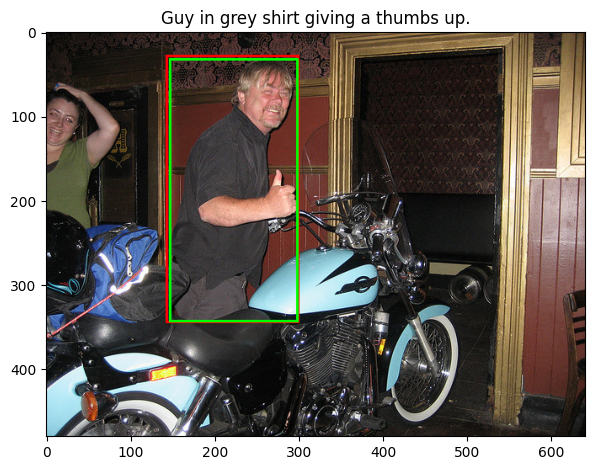

In [335]:
# Show image
plt.title(sentence)
plt.imshow(image.permute(1,2,0))
plt.tight_layout()
plt.show()

In [ ]:
yolo = YOLO("../checkpoints/yolov8n.pt")

In [ ]:
NUM_EPOCHS = 1
count = 0
iou_threshold = 0.5
loss_meter = MetricMeter(name = 'ZeroShot', threshold=iou_threshold)

running_loc_acc = 0.0
correct_bboxes = 0
overall = 0
semantic = 0
semantic_similarity = 0
running_ga = 0
sem = 0
loc_acc = 0


In [ ]:
loss_meter.reset()

In [ ]:
loop = tqdm(dataloader_test, position=0, leave=True)
for iter in enumerate(loop):
    try:
        data = iter[1][1]

        raw_text = data['raw']
        bbox_gt = data['bbox']
        filename = data['filename']
        # since confidence is directly how much bbox and text "resembles" each other 
        confidence, bbox_e = ZeroShotter.calculate_best_bbox(filename,raw_text)
        bbox_e = [int(bbox_e[0]), int(bbox_e[1]), int(bbox_e[2]), int(bbox_e[3])]
        # print(bbox_e)
        
        # for bbox_e in candidates:
        #     pred = compute_iou(bbox_gt,bbox_e[1])
        #     if pred > max_iou:
        #         max_iou = pred
        #     #print(pred)
        iou = compute_iou(bbox_gt,bbox_e)
        running_loc_acc += iou

        confidence = confidence[0]

        if(iou > iou_threshold):
                #compare_candidate_bbox(filename,bbox_e, bbox_gt)
            correct_bboxes += 1
            overall += 1
            running_ga = correct_bboxes / overall
        else:
            overall += 1
            running_ga = correct_bboxes / overall

        # semantic = confidence[0] / 100
        sem += confidence
        semantic_similarity = sem / overall
        loc_acc = running_loc_acc / overall
        loss_meter.update(iou, confidence, filename,bbox_e,bbox_gt)
        #loss_meter.print_iteration()

    except Exception as e:
        print("diocan")
        print(e)

    loop.set_description(f"Localization accuracy = {loc_acc}, Grounding Accuracy = {running_ga}, Semantic Similarity = {semantic_similarity}")
    
loss_meter.writer.close()

  0%|          | 0/601 [00:00<?, ?it/s]

TypeError: pic should be PIL Image. Got <class 'numpy.ndarray'>

In [ ]:
alfa = loss_meter.get_best_iou_cases()

# Training

In [ ]:
path = "../refcocog/images/COCO_train2014_000000079887.jpg"

## Trial Class

In [ ]:
##########################################################
# YolottoClip - Just for Zero-Shotting the dataset
##########################################################
MOMENTUM = 0.1 #Default should be 3e-4
class ConvBNReLU(nn.Module):
    '''Module for the Conv-BN-ReLU tuple.'''

    def __init__(self, c_in, c_out, kernel_size, stride, padding, dilation):
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(
                c_in, c_out, kernel_size=kernel_size, stride=stride, 
                padding=padding, dilation=dilation, bias=False)
        self.bn = nn.SyncBatchNorm(c_out, momentum=MOMENTUM)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class External_attention(nn.Module):

    '''
    Arguments:
        c (int): The input and output channel number.
    '''
    def __init__(self, c):
        super(External_attention, self).__init__()
        
        self.conv1 = nn.Conv2d(c, c, 1) #Convolution to linear layer
        self.al4 = 0
        self.k = 64
        self.fc0 = ConvBNReLU(2048, 512, 3, 1, 1, 1)
        self.linear_0 = nn.Conv1d(c, self.k, 1, bias=False)
        self.norm_layer = nn.SyncBatchNorm(c, momentum=MOMENTUM)
        self.linear_1 = nn.Conv1d(self.k, c, 1, bias=False)
        self.linear_1.weight.data = self.linear_0.weight.data.permute(1, 0, 2)        
        self.fc1 = nn.Sequential(
            ConvBNReLU(512, 256, 3, 1, 1, 1),
            nn.Dropout2d(p=0.1))
        self.conv2 = nn.Sequential(
            nn.Conv2d(c, c, 1, bias=False),
            self.norm_layer)    
        self.fc2 = nn.Conv2d(256, 80, 1)    
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d): # Kaiming Initialiaztion
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.Conv1d):# He Initialization
                n = m.kernel_size[0] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, _BatchNorm): # BatchNorm Initialization all setted to 1
                m.weight.data.fill_(1)
                if m.bias is not None:
                    m.bias.data.zero_()

    def forward(self, x):
        x = self.fc0(x)
        idn = x
        x = self.conv1(x)

        b, c, h, w = x.size()
        n = h*w
        x = x.view(b, c, n)   # b * c * n 

        attn = self.linear_0(x) # b, k, n
        attn = F.softmax(attn, dim=-1) # b, k, n

        attn = attn / (1e-9 + attn.sum(dim=1, keepdim=True)) #  # b, k, n
        x = self.linear_1(attn) # b, c, n

        x = x.view(b, c, h, w)
        x = self.conv2(x)
        x = x + idn
        x = F.relu(x)
        x = self.fc1(x)
        #x = self.fc2(x)

        return x
    
class ExternalYoloClip(nn.Module):
    def __init__(self, clip_model, clip_preprocess):
        super(ExternalYoloClip, self).__init__()
        self.yolo = YOLO("yolov8n.pt")
        self.EA = External_attention(512)
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def infer_bboxes(self, image_path):
        results = self.yolo(image_path, verbose=False)
        bboxes = results[0].boxes.xyxy
        return bboxes

    def encode_image(self, image):
        # Load and preprocess the image using CLIP preprocess function
        image = self.clip_preprocess(image).unsqueeze(0).to(device)

        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features

    def encode_text(self, text):
        # Encode the text using the CLIP model
        text = clip.tokenize(text).to(device)
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)

        return text_features
    def hook_fn(self, module, input, output):
        self.al = output

    def forward(self, image, text):
        
        #bl = 0 # input of layer4 of CLIP's ResNet
        hook_handle = clip_model.visual.layer4.register_forward_hook(self.hook_fn) # handle to retrieve output

        image_features = self.encode_image(image)
        text_features = self.encode_text(text)
        print(self.al.shape)
        image_features = self.EA(self.al)

        print(image_features.shape)

        # normalized features
        image_features = image_features / image_features.norm(dim=1, keepdim=True)
        text_features = text_features / text_features.norm(dim=1, keepdim=True)
        logit_scale = self.logit_scale.exp()
        print(text_features.shape)
        # cosine similarity as logits
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()

        # shape = [global_batch_size, global_batch_size]
        hook_handle.remove()
        return logits_per_image, logits_per_text
    
    def calculate_best_bbox(self, image_path, caption):
        best_score = 0
        best_bbox = None
        candidates = []

        for bbox in self.infer_bboxes(image_path):
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = Image.fromarray(image)
            #image = self.clip_preprocess(image).unsqueeze(0).to(device)

            with torch.no_grad():
                logits_per_image, logits_per_text = self.forward(image, caption)
                matching_score = logits_per_text.cpu().numpy()[0]

            candidates.append((matching_score,bbox))

            if matching_score > best_score:
                best_score = matching_score
                best_bbox = bbox
                logit_text = logits_per_text
                logit_img = logits_per_image

        return best_score, best_bbox, candidates, logit_img, logit_text
    

In [ ]:
NUM_EPOCHS = 10
count = 0
iou_threshold = 0.5
loss_meter = MetricMeter(name = 'TrainingEA', threshold=iou_threshold)

running_loc_acc = 0.0
correct_bboxes = 0
overall = 0
semantic = 0
semantic_similarity = 0
running_ga = 0
sem = 0
loc_acc = 0
model = ExternalYoloClip(clip_model,clip_preprocess)

In [ ]:
loss_meter.reset()

In [ ]:
lr = 0.0001
wd = 0.002
alpha = 1 # to decrease lr over time

In [ ]:
cost = nn.CrossEntropyLoss()
optimizer = torch.optim.Adadelta(model.parameters(), lr=lr, weight_decay = wd)

In [ ]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0

loop = tqdm(dataloader_test, position=0, leave=True)
for iter in enumerate(loop):

    optimizer.zero_grad()

    # Build Data for training pass
    data = iter[1][1]
    raw_text = data['raw']
    bbox_gt = data['bbox']
    filename = data['filename']

    # since confidence is directly how much bbox and text "resembles" each other 
    confidence, bbox_e, candidates, li, lt = model.calculate_best_bbox(filename,raw_text)
    bbox_e = [int(bbox_e[0]), int(bbox_e[1]), int(bbox_e[2]), int(bbox_e[3])]

    # Construct the ground truth
    ground_truth = torch.arange(len(filename),dtype=torch.long,device=device)
    img_loss = cost(li, ground_truth)
    txt_loss = cost(lt, ground_truth)
    print(img_loss)
    print(txt_loss)

    loss = (img_loss + txt_loss)/2
    print(loss)
    loss.backward()
    optimizer.step()

    cumulative_loss += loss.item()
    _, predicted = li.max(dim=1)
    cumulative_accuracy += predicted.eq(ground_truth).sum().item()

    iou = compute_iou(bbox_gt,bbox_e)
    running_loc_acc += iou
    break
    confidence = confidence[0]

    if(iou > iou_threshold):
        #compare_candidate_bbox(filename,bbox_e, bbox_gt)
        correct_bboxes += 1
        overall += 1
        running_ga = correct_bboxes / overall
    else:
        overall += 1
        running_ga = correct_bboxes / overall

    # semantic = confidence[0] / 100
    sem += confidence
    semantic_similarity = sem / overall
    loc_acc = running_loc_acc / overall
    loss_meter.update(iou, confidence, filename,bbox_e,bbox_gt)
    #loss_meter.print_iteration()

#loop.set_description(f"Loss Iter = {cumulative_loss/overall}, Accuracy = {cumulative_accuracy/overall}, Localization accuracy = {loc_acc}, Grounding Accuracy = {running_ga}, Semantic Similarity = {semantic_similarity}")
    
loss_meter.writer.close()

  0%|          | 0/601 [00:00<?, ?it/s]

torch.Size([1, 2048, 7, 7])
torch.Size([1, 256, 7, 7])
torch.Size([1, 1024])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1792x7 and 1024x1)